In [3]:
# ============================================================
# Rank-8 MoA Tensor -> Flatten -> Doob Markov Kernel -> Minorization Gap Bound
# Self-contained, Colab-ready.
# ============================================================

import numpy as np
import cmath
import functools
from typing import Dict, Any, Tuple, Optional

# -----------------------
# If you're using JAX elsewhere, fine; this block is pure NumPy for determinism.
# -----------------------

# ============================================================
# 1) Robust q-kernel from MoA session (cached q-number, q-factorial, q-Delta, q-6j)
# ============================================================

@functools.lru_cache(maxsize=None)
def _cached_q_number(n: float, q: complex) -> complex:
    """[n]_q = (q^n - q^{-n})/(q - q^{-1}), with safe fallbacks near q=±1."""
    if np.isclose(q, 1.0):
        return float(n)
    if np.isclose(q, -1.0):
        # crude but consistent with MoA snippet idea: degeneracies near -1
        return float(n) if (int(round(2*n)) % 2 == 1) else 0.0

    denom = q - 1.0/q
    if abs(denom) < 1e-14:
        return float(n)
    return (q**n - q**(-n)) / denom


@functools.lru_cache(maxsize=None)
def _cached_log_q_factorial(n: float, q: complex) -> complex:
    """log([n]_q!) computed in log-space. n is expected to be integer-valued."""
    if n < 0:
        return -np.inf + 0j
    if n == 0:
        return 0.0j

    res = 0.0j
    for k in np.arange(1.0, float(n) + 0.1, 1.0):
        val = _cached_q_number(k, q)
        if abs(val) < 1e-14:
            return -np.inf + 0j
        res += cmath.log(val)
    return res


@functools.lru_cache(maxsize=None)
def _cached_q_delta_log(j1: float, j2: float, j3: float, q: complex) -> complex:
    """log Delta_q for triangle (j1,j2,j3). Returns -inf if incoherent."""
    if not (abs(j1 - j2) <= j3 <= j1 + j2):
        return -np.inf + 0j
    if not ((j1 + j2 + j3) % 1.0 == 0.0):
        return -np.inf + 0j

    a1 = j1 + j2 - j3
    a2 = j1 - j2 + j3
    a3 = -j1 + j2 + j3
    a4 = j1 + j2 + j3 + 1

    l1 = _cached_log_q_factorial(a1, q)
    l2 = _cached_log_q_factorial(a2, q)
    l3 = _cached_log_q_factorial(a3, q)
    l4 = _cached_log_q_factorial(a4, q)

    if any(np.isinf(x.real) and x.real < 0 for x in [l1, l2, l3, l4]):
        return -np.inf + 0j

    return 0.5 * (l1 + l2 + l3 - l4)


@functools.lru_cache(maxsize=None)
def _cached_quantum_6j_symbol(j1: float, j2: float, j3: float,
                             j4: float, j5: float, j6: float,
                             q: complex) -> complex:
    """Quantum 6j-symbol {j1 j2 j3; j4 j5 j6}_q via Racah sum (MoA kernel)."""
    triangles = [(j1, j2, j3), (j1, j5, j6), (j4, j2, j6), (j4, j5, j3)]
    for (a, b, c) in triangles:
        if not (abs(a - b) <= c <= a + b):
            return 0.0j
        if not ((a + b + c) % 1.0 == 0.0):
            return 0.0j

    log_deltas = [_cached_q_delta_log(*t, q) for t in triangles]
    if any(np.isinf(d.real) for d in log_deltas):
        return 0.0j
    log_prefactor = sum(log_deltas)

    k_min_val = max(j1 + j2 + j3, j1 + j5 + j6, j4 + j2 + j6, j4 + j5 + j3)
    k_max_val = min(j1 + j2 + j4 + j5, j2 + j3 + j5 + j6, j3 + j1 + j6 + j4)

    # These should be integers when triangles are coherent; do robust rounding.
    k_min = int(round(k_min_val))
    k_max = int(round(k_max_val))

    sum_val = 0.0j
    for k in range(k_min, k_max + 1):
        log_num = cmath.log((-1)**k) + _cached_log_q_factorial(k + 1, q)
        den_args = [
            k - j1 - j2 - j3,
            k - j1 - j5 - j6,
            k - j4 - j2 - j6,
            k - j4 - j5 - j3,
            j1 + j2 + j4 + j5 - k,
            j2 + j3 + j5 + j6 - k,
            j3 + j1 + j6 + j4 - k,
        ]
        log_den = sum(_cached_log_q_factorial(arg, q) for arg in den_args)
        term = cmath.exp(log_prefactor + log_num - log_den)
        sum_val += term

    return sum_val


def clear_q_caches():
    _cached_q_number.cache_clear()
    _cached_log_q_factorial.cache_clear()
    _cached_q_delta_log.cache_clear()
    _cached_quantum_6j_symbol.cache_clear()


# ============================================================
# 2) Rank-8 tensor builder (MoA-style: external weight product + internal k-sum)
# ============================================================

def build_rank8_T_moa(
    beta: float,
    j_max: float,
    theta: float = 0.0,
    q_override: Optional[complex] = None,
    progress_every: int = 20000,
) -> np.ndarray:
    """
    Constructs rank-8 tensor T_{x+ x- y+ y- z+ z- t+ t-}.

    MoA-style structure:
      - spins are j in {0, 1/2, ..., j_max}
      - weights[j] = exp(-beta * j(j+1))
      - for external indices (8 legs): w_prod = Π weights[j_leg]
      - internal sum over k in same set:
            term_sum = Σ_k weights[k] * 6j(j0,j1,k,j2,j3,k) * 6j(j4,j5,k,j6,j7,k)
      - T[idxs] = w_prod * term_sum
    """
    if q_override is None:
        q = cmath.exp(1j * theta)
    else:
        q = complex(q_override)

    # spins: 0, 1/2, ..., j_max
    j_vals = np.array([0.5 * i for i in range(int(round(2 * j_max)) + 1)], dtype=float)
    dim = len(j_vals)

    # external/internal weights
    weights = np.exp(-beta * j_vals * (j_vals + 1.0))  # positive real

    T = np.zeros((dim,) * 8, dtype=np.complex128)

    total = dim**8
    for count, idxs in enumerate(np.ndindex((dim,) * 8)):
        js = j_vals[list(idxs)]
        w_prod = float(np.prod(weights[list(idxs)]))

        term_sum = 0.0j
        for k_idx, k_val in enumerate(j_vals):
            w_k = float(weights[k_idx])

            s6j_1 = _cached_quantum_6j_symbol(js[0], js[1], k_val, js[2], js[3], k_val, q)
            if abs(s6j_1) < 1e-15:
                continue

            s6j_2 = _cached_quantum_6j_symbol(js[4], js[5], k_val, js[6], js[7], k_val, q)
            if abs(s6j_2) < 1e-15:
                continue

            term_sum += w_k * s6j_1 * s6j_2

        T[idxs] = w_prod * term_sum

        if progress_every and (count % progress_every == 0) and (count > 0):
            print(f"[build_rank8_T_moa] {count:,}/{total:,}  ({100*count/total:.2f}%)")

    # Normalize (scale irrelevant for Doob transform, but helps numerics)
    norm = np.max(np.abs(T))
    if norm > 1e-30:
        T = T / norm

    return T


# ============================================================
# 3) Flattening and optional SVD "weave" truncation on flattened matrix
# ============================================================

def flatten_rank8_to_matrix(T8: np.ndarray) -> np.ndarray:
    """Group first 4 legs as row-index, last 4 legs as col-index: (d^4, d^4)."""
    d = T8.shape[0]
    return T8.reshape(d**4, d**4)


def svd_weave_truncate_matrix(M: np.ndarray, chi: int) -> Tuple[np.ndarray, Dict[str, Any]]:
    """
    SVD truncation of M: keep top-chi singular values (rank truncation).
    Does NOT change matrix dimension, only reduces effective rank.
    """
    U, S, Vh = np.linalg.svd(M, full_matrices=False)
    chi_eff = min(chi, S.size)
    Uc = U[:, :chi_eff]
    Sc = S[:chi_eff]
    Vhc = Vh[:chi_eff, :]
    M_trunc = (Uc * Sc[None, :]) @ Vhc

    info = dict(chi_eff=chi_eff, S0=float(S[0]), S_chi=float(Sc[-1]), kept_weight=float(np.sum(Sc)/np.sum(S)))
    return M_trunc, info


# ============================================================
# 4) Make a nonnegative transfer matrix, Doob transform, minorization bound
# ============================================================

def make_nonnegative_matrix(M: np.ndarray, mode: str = "abs", reg_eps: float = 0.0) -> np.ndarray:
    """
    Produce entrywise-nonnegative matrix required for Doob/minorization tooling.
    mode:
      - "abs": |M_ij|
      - "real_pos": max(Re M_ij, 0)
      - "real_shift": Re M_ij shifted so min becomes 0
    reg_eps: add small constant to avoid exact zeros (optional).
    """
    if mode == "abs":
        K = np.abs(M)
    elif mode == "real_pos":
        K = np.maximum(M.real, 0.0)
    elif mode == "real_shift":
        K = M.real.copy()
        K -= K.min()
    else:
        raise ValueError(f"Unknown mode={mode}")

    if reg_eps > 0:
        K = K + reg_eps

    return K.astype(np.float64)


def pf_power_iteration(M: np.ndarray, max_iter: int = 20000, tol: float = 1e-13) -> Tuple[float, np.ndarray]:
    """
    Perron-Frobenius eigenpair for entrywise-nonnegative M using simplex power iteration.

    We keep v as a probability vector (sum(v)=1).
    If w = M v, then lambda = sum(w), and v_new = w/lambda.
    """
    n = M.shape[0]
    v = np.ones(n, dtype=np.float64) / n
    lam = 0.0

    for t in range(max_iter):
        w = M @ v
        lam_new = float(w.sum())
        if lam_new <= 0:
            raise ValueError("PF iteration failed: nonpositive lambda.")
        v_new = w / lam_new

        if np.max(np.abs(v_new - v)) < tol:
            lam = lam_new
            v = v_new
            break

        lam = lam_new
        v = v_new

    return lam, v


def doob_transform_from_transfer(M: np.ndarray) -> Tuple[float, np.ndarray, np.ndarray]:
    """
    Given entrywise nonnegative transfer matrix M, produce Doob Markov kernel:
      P_ij = M_ij * v_j / (lambda * v_i)
    where M v = lambda v.
    """
    lam, v = pf_power_iteration(M)
    P = (M * v[None, :]) / (lam * v[:, None])
    P = P / P.sum(axis=1, keepdims=True)  # numeric cleanup
    return lam, v, P


def minorization_epsilon(P: np.ndarray) -> Tuple[float, np.ndarray]:
    """
    Doeblin minorization:
      m_j = min_i P_ij
      eps = sum_j m_j
      nu_j = m_j/eps
    so P(i,·) >= eps * nu(·) for all i.
    """
    m = P.min(axis=0)
    eps = float(m.sum())
    if eps > 0:
        nu = m / eps
    else:
        nu = m  # meaningless if eps=0, but keep shape
    return eps, nu


def best_minorization_bound(P: np.ndarray, k_max: int = 8) -> Dict[str, Any]:
    """
    Try eps_k for P^k, k=1..k_max.
    If eps_k>0:
      |lambda2(P)| <= (1 - eps_k)^(1/k)
      m >= -(1/k) log(1-eps_k)
    """
    n = P.shape[0]
    Pk = np.eye(n, dtype=np.float64)

    best = dict(
        k=None,
        eps=0.0,
        lam2_bound=1.0,
        gap_bound=0.0,
        mass_bound=0.0,
    )

    for k in range(1, k_max + 1):
        Pk = Pk @ P
        eps_k, _ = minorization_epsilon(Pk)

        if eps_k > 0:
            lam2_bound = (1.0 - eps_k) ** (1.0 / k)
            gap_bound = 1.0 - lam2_bound
            mass_bound = -(1.0 / k) * np.log(max(1.0 - eps_k, 1e-300))

            # Prefer larger mass_bound (stronger)
            if mass_bound > best["mass_bound"]:
                best = dict(
                    k=k,
                    eps=eps_k,
                    lam2_bound=lam2_bound,
                    gap_bound=gap_bound,
                    mass_bound=mass_bound,
                )

    return best


def spectral_stats_markov(P: np.ndarray) -> Dict[str, Any]:
    """Exact eigen spectrum for small-ish dense P."""
    eig = np.linalg.eigvals(P)
    abs_sorted = np.sort(np.abs(eig))[::-1]
    lam1 = abs_sorted[0]   # should be ~1
    lam2 = abs_sorted[1] if len(abs_sorted) > 1 else 0.0
    gap = float(1.0 - lam2)
    mass = float(-np.log(max(lam2, 1e-300)))
    return dict(lam1=float(lam1), lam2=float(lam2), gap=gap, mass=mass)


# ============================================================
# 5) End-to-end runner
# ============================================================

def run_rank8_transfer_gap(
    beta: float = 0.8,
    j_max: float = 1.0,
    theta: float = 0.0,
    q_override: Optional[complex] = None,
    positivity_mode: str = "abs",
    reg_eps: float = 1e-15,
    k_minor_max: int = 8,
    svd_chi: Optional[int] = None,
    progress_every: int = 20000,
) -> Dict[str, Any]:
    """
    Build MoA rank-8 tensor, flatten, Doob transform, compute (actual gap, minorization bound).
    """
    clear_q_caches()

    print("=== Building rank-8 tensor T8 (MoA-style) ===")
    T8 = build_rank8_T_moa(beta=beta, j_max=j_max, theta=theta, q_override=q_override, progress_every=progress_every)

    d = T8.shape[0]
    print(f"T8 shape: {T8.shape}  (d={d}, total entries={d**8:,})")
    print(f"T8 max|.| = {np.max(np.abs(T8)):.3e}   nonzero ~ {np.sum(np.abs(T8) > 1e-18):,}")

    print("\n=== Flatten to transfer matrix M ===")
    M = flatten_rank8_to_matrix(T8)
    n = M.shape[0]
    print(f"M shape: {M.shape}  (n=d^4={n})")

    if svd_chi is not None:
        print("\n=== SVD weave truncation (rank truncation) ===")
        M, info = svd_weave_truncate_matrix(M, chi=svd_chi)
        print(f"  kept chi={info['chi_eff']} singular values; kept_weight≈{info['kept_weight']:.6f}")

    print("\n=== Make entrywise-nonnegative matrix K for Doob/minorization ===")
    K = make_nonnegative_matrix(M, mode=positivity_mode, reg_eps=reg_eps)
    print(f"K min={K.min():.3e}, max={K.max():.3e}, density={(K>0).mean():.4f}")

    print("\n=== Doob transform: K -> Markov kernel P ===")
    lam_pf, v_pf, P = doob_transform_from_transfer(K)
    rowsum_err = np.max(np.abs(P.sum(axis=1) - 1.0))
    print(f"PF lambda(K) ≈ {lam_pf:.12e}")
    print(f"Row-sum max error (should be ~0): {rowsum_err:.3e}")

    print("\n=== Actual spectrum of P (dense eig) ===")
    spec = spectral_stats_markov(P)
    print(f"|lambda2(P)| ≈ {spec['lam2']:.12e}")
    print(f"Markov spectral gap 1-|λ2| ≈ {spec['gap']:.12e}")
    print(f"Mass gap m = -log|λ2| ≈ {spec['mass']:.12e}")

    print("\n=== Minorization / Doeblin bound via P^k ===")
    bound = best_minorization_bound(P, k_max=k_minor_max)
    if bound["k"] is None:
        print("No positive minorization found up to k_max (eps_k stayed 0). Try larger k_max or add reg_eps.")
    else:
        print(f"Best at k={bound['k']}: eps_k={bound['eps']:.12e}")
        print(f"  => |λ2(P)| <= (1-eps_k)^(1/k) ≈ {bound['lam2_bound']:.12e}")
        print(f"  => gap(P) >= 1 - bound ≈ {bound['gap_bound']:.12e}")
        print(f"  => mass gap m >= -(1/k)log(1-eps_k) ≈ {bound['mass_bound']:.12e}")

    out = dict(
        beta=beta, j_max=j_max, theta=theta, q_override=q_override,
        d=d, n=n,
        T8=T8, M=M, K=K, P=P,
        pf_lambda=lam_pf,
        spec=spec,
        minorization_bound=bound,
    )
    return out


# ============================================================
# RUN: choose parameters here
# ============================================================

# Practical default: j_max=1.0 => d=3 => M is 81x81 (fast)
# You can push to j_max=1.5 (d=4 => 256x256) or j_max=2.0 (d=5 => 625x625).
results = run_rank8_transfer_gap(
    beta=0.8,
    j_max=1.0,
    theta=0.10,            # MoA convention q = exp(i theta). Set 0.0 for "no phase".
    q_override=None,       # or set q_override=0.95 for real-q experiments
    positivity_mode="abs", # crucial for Doob/minorization: needs nonnegative entries
    reg_eps=1e-15,         # tiny positivity regularizer (set 0.0 to see exact zeros)
    k_minor_max=8,
    svd_chi=None,          # or svd_chi=20 etc (rank truncation of flattened matrix)
    progress_every=0       # set e.g. 20000 for progress printing at higher d
)

print("\nDONE.")


=== Building rank-8 tensor T8 (MoA-style) ===
T8 shape: (3, 3, 3, 3, 3, 3, 3, 3)  (d=3, total entries=6,561)
T8 max|.| = 1.000e+00   nonzero ~ 133

=== Flatten to transfer matrix M ===
M shape: (81, 81)  (n=d^4=81)

=== Make entrywise-nonnegative matrix K for Doob/minorization ===
K min=1.000e-15, max=1.000e+00, density=1.0000

=== Doob transform: K -> Markov kernel P ===
PF lambda(K) ≈ 1.002078563416e+00
Row-sum max error (should be ~0): 2.220e-16

=== Actual spectrum of P (dense eig) ===
|lambda2(P)| ≈ 3.334934629969e-02
Markov spectral gap 1-|λ2| ≈ 9.666506537003e-01
Mass gap m = -log|λ2| ≈ 3.400717108021e+00

=== Minorization / Doeblin bound via P^k ===
Best at k=8: eps_k=9.999999999957e-01
  => |λ2(P)| <= (1-eps_k)^(1/k) ≈ 3.791449376622e-02
  => gap(P) >= 1 - bound ≈ 9.620855062338e-01
  => mass gap m >= -(1/k)log(1-eps_k) ≈ 3.272421818726e+00

DONE.



positivity_mode=abs, reg_eps=1.0e-18
K: min=1.000e-18, max=1.000e+00, density=1.000000
PF lambda(K)=1.002078563416e+00
|lambda2(P)|=8.547114117709e-01  =>  m=-log|λ2|=1.569913971140e-01
Minorization best: k=64, eps_k=9.999553582954e-01, m_bound=1.565131571037e-01

positivity_mode=abs, reg_eps=1.0e-15
K: min=1.000e-15, max=1.000e+00, density=1.000000
PF lambda(K)=1.002078563416e+00
|lambda2(P)|=3.334934629969e-02  =>  m=-log|λ2|=3.400717108021e+00
Minorization best: k=9, eps_k=9.999999999999e-01, m_bound=3.282568305698e+00


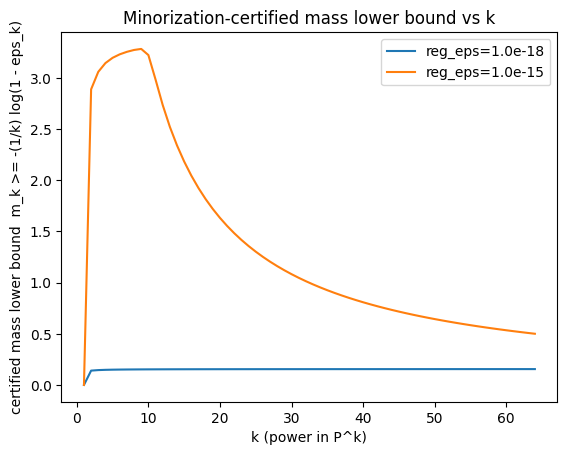

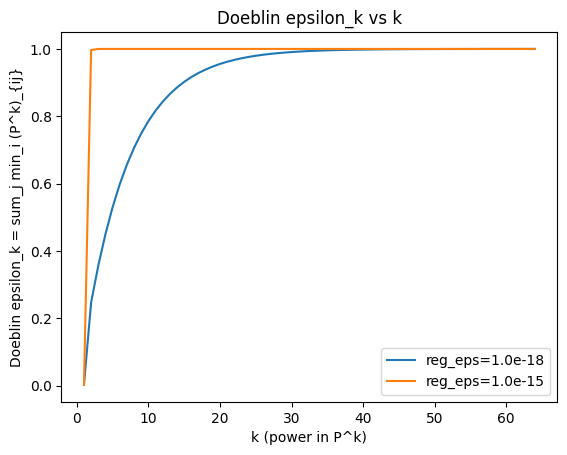

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# This cell assumes you already ran the previous script and have:
#  - results dict (from run_rank8_transfer_gap)
#  - make_nonnegative_matrix, doob_transform_from_transfer
#  - minorization_epsilon, best_minorization_bound, spectral_stats_markov
# If not, re-run the previous big cell first.

M = results["M"]  # flattened transfer matrix (possibly complex)

def eps_curve_and_mass_bound(P, k_max=64):
    """
    Compute eps_k for P^k and the implied mass lower bound:
      m_k >= -(1/k) log(1 - eps_k)
    """
    n = P.shape[0]
    Pk = np.eye(n, dtype=np.float64)
    eps = np.zeros(k_max, dtype=np.float64)
    m_lb = np.zeros(k_max, dtype=np.float64)

    for k in range(1, k_max + 1):
        Pk = Pk @ P
        eps_k, _ = minorization_epsilon(Pk)
        eps[k-1] = eps_k
        m_lb[k-1] = -(1.0/k) * np.log(max(1.0 - eps_k, 1e-300))

    return eps, m_lb

def analyze_from_M(M, positivity_mode="abs", reg_eps=0.0, k_max=64):
    # Build nonnegative kernel
    K = make_nonnegative_matrix(M, mode=positivity_mode, reg_eps=reg_eps)
    density = float((K > 0).mean())
    minK, maxK = float(K.min()), float(K.max())

    # Doob -> Markov
    lam_pf, v_pf, P = doob_transform_from_transfer(K)

    # Actual spectral stats
    spec = spectral_stats_markov(P)

    # Best minorization bound among k<=k_max
    bound = best_minorization_bound(P, k_max=k_max)

    # eps_k curve and certified mass bounds
    eps_k, m_lb_k = eps_curve_and_mass_bound(P, k_max=k_max)

    out = dict(
        reg_eps=reg_eps,
        positivity_mode=positivity_mode,
        K=K, P=P,
        density=density,
        minK=minK, maxK=maxK,
        pf_lambda=lam_pf,
        spec=spec,
        bound=bound,
        eps_k=eps_k,
        m_lb_k=m_lb_k
    )
    return out

# ---- Run the sensitivity sweep ----
k_max = 64
configs = [
    # dict(reg_eps=0.0), # Removed: Setting reg_eps=0.0 can lead to numerical instability.
    dict(reg_eps=1e-18),
    dict(reg_eps=1e-15),
]

outs = []
for cfg in configs:
    out = analyze_from_M(M, positivity_mode="abs", reg_eps=cfg["reg_eps"], k_max=k_max)
    outs.append(out)

    print("\n==============================")
    print(f"positivity_mode=abs, reg_eps={out['reg_eps']:.1e}")
    print(f"K: min={out['minK']:.3e}, max={out['maxK']:.3e}, density={out['density']:.6f}")
    print(f"PF lambda(K)={out['pf_lambda']:.12e}")
    print(f"|lambda2(P)|={out['spec']['lam2']:.12e}  =>  m=-log|λ2|={out['spec']['mass']:.12e}")
    if out["bound"]["k"] is None:
        print("Minorization: eps_k stayed 0 up to k_max (no certified Doeblin bound yet).")
    else:
        b = out["bound"]
        print(f"Minorization best: k={b['k']}, eps_k={b['eps']:.12e}, m_bound={b['mass_bound']:.12e}")

# ---- Plot: certified mass lower bound vs k ----
plt.figure()
for out in outs:
    label = f"reg_eps={out['reg_eps']:.1e}"
    plt.plot(np.arange(1, k_max+1), out["m_lb_k"], label=label)
plt.xlabel("k (power in P^k)")
plt.ylabel("certified mass lower bound  m_k >= -(1/k) log(1 - eps_k)")
plt.yscale("linear")
plt.legend()
plt.title("Minorization-certified mass lower bound vs k")
plt.show()

# ---- Plot: epsilon_k vs k ----
plt.figure()
for out in outs:
    label = f"reg_eps={out['reg_eps']:.1e}"
    plt.plot(np.arange(1, k_max+1), out["eps_k"], label=label)
plt.xlabel("k (power in P^k)")
plt.ylabel("Doeblin epsilon_k = sum_j min_i (P^k)_{ij}")
plt.yscale("linear")
plt.legend()
plt.title("Doeblin epsilon_k vs k")
plt.show()
